# Cls vs map-level constraining power — where do I land vs the papers? (blinded)

A copy of `lensing_cls_constraining_power.ipynb` restructured to compare **two of my runs** — a
**Cls** run and a **map-level** run — against each other and against the published DES Y3 references,
for **both wCDM and ΛCDM** where available.

**Goal:** a rough, at-a-glance sense of where my lensing constraining power sits relative to the
reference papers. Set both runs at the top; the *Overview* section is the headline.

Blinding is unchanged: every posterior is translated so its MAP (or mean, if no `log_probs`) sits at
the fiducial cosmology — only sizes / error bars / FoM (`det(Cov)^(-1/2)`, shift-invariant) are
meaningful.

> ⚠️ **Scale cuts are NOT matched** (Cls uses `lmax_1024`; map-level `t6_default` uses its own
> full-resolution maps) and **training steps differ** (1M vs 150k). So a Cls-vs-map difference mixes
> statistic + scale cut + training budget — read it as *indicative*, not a controlled ablation.

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt

from msfm.utils import files as msfm_files, parameters, prior
from msi.utils import plotting, diagnostics

# =================================================================================================
# TWO RUNS TO COMPARE. Each: base dir + model_name + training step (its ensemble_flow_<steps> subdir).
# =================================================================================================
CLS_RUN = dict(label="Cls",       base="/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/lensing",
               model="m1_default", steps=1_000_000, scales="lmax_1024")
MAP_RUN = dict(label="map-level", base="/users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/maps/lensing",
               model="t6_default", steps=150_000,   scales="full-res (unmatched)")
RUNS = [CLS_RUN, MAP_RUN]

FLOW_NAME   = "ensemble_flow"
MSFM_CONFIG = "/users/athomsen/dlss/repos/multiprobe-simulation-forward-model/configs/v16/rot_in_place.yaml"

# training-order params of the lensing flows
PARAMS      = ["Om", "s8", "w0", "Aia", "n_Aia", "bta"]
PARAMS_NLA  = [p for p in PARAMS if p != "bta"]   # w0>-1 & NLA: bta dropped
PARAMS_LCDM = [p for p in PARAMS if p != "w0"]    # lambdaCDM: w0 dropped (fixed to -1)

# DES posterior variants to try per run (loaded only if the chain file exists). model: wCDM / LCDM.
VARIANTS = [("wCDM",        "DESy3",             PARAMS,      "wCDM"),
            ("w0>-1",       "DESy3_w0gt-1",      PARAMS,      "wCDM"),
            ("w0>-1 & NLA", "DESy3_w0gt-1_nla",  PARAMS_NLA,  "wCDM"),
            ("lambdaCDM",   "DESy3_lambdaCDM",   PARAMS_LCDM, "LCDM")]

# ------------------------------------------------------------------------------------------------
# Published reference chains we have actual samples for on disk (not just transcribed numbers).
# `cols` gives the column meaning; `variants` lists which of my variants this chain is comparable to
# (matched w0 prior) so it can be overlaid on the corresponding contour panels.
# The "W26 hybrid" chain was matched to Table 3 of 2606.11309 (Williamson+26): its FoMs reproduce the
# hybrid row (Om-S8 2621~2614, Om-w0 469~470, S8-w0 590~592, Om-S8-w0 29422~29444).
# ------------------------------------------------------------------------------------------------
REF_CHAIN_FILES = {
    "W26 hybrid": dict(
        paper="Williamson", model="wCDM", stat="hybrid map stats", variants=["w0>-1"],
        path="/users/athomsen/dlss/repos/multiprobe-simulation-inference/data/DESy3_sbi/"
             "hybrid_chains_Y3_postunblind_LCDM_LONGRUN.npz",
        key="chains", cols=["Om", "S8", "w0"]),
}

# One color per SOURCE. My results (Thomsen+25) get their own color; each reference paper gets one.
PAPER_COLORS = {
    "Thomsen":    "#1f77b4",  # blue   - this work
    "Jeffrey":    "#ff7f0e",  # orange - Jeffrey+2024/2025
    "Williamson": "#2ca02c",  # green  - Williamson+2026
    "Gatti":      "#d62728",  # red    - Gatti+2024
}
PAPER_LABEL = {"Thomsen": "Thomsen+25 (this work)", "Jeffrey": "Jeffrey+24/25",
               "Williamson": "Williamson+26", "Gatti": "Gatti+24"}

# Two shades of the "this work" color for my two runs where they must be told apart within one panel.
MINE_COLORS = ["#1f77b4", "#9467bd"]   # Cls, map-level

def color_of(paper):
    return PAPER_COLORS.get(paper, "0.6")

for r in RUNS:
    r["fdir"] = os.path.join(r["base"], r["model"], f"{FLOW_NAME}_{r['steps']}")
    print(f"{r['label']:10s} -> {r['fdir']}  exists={os.path.isdir(r['fdir'])}")

msfm_conf = msfm_files.load_config(MSFM_CONFIG)

Cls        -> /users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/cls/lensing/m1_default/ensemble_flow_1000000  exists=True
map-level  -> /users/athomsen/scratch/deep_lss/runs/v16/rot_in_place/maps/lensing/t6_default/ensemble_flow_150000  exists=True


In [13]:
# Loading + blinded-shift + FoM helpers (shared with the parent notebook, parametrised by flow dir).
def slice_chain(chain, chain_params, test_params):
    """Slice a raw chain to test_params. S8 is taken natively if present, else derived
    S8 = sigma8 * sqrt(Om/0.3) (my flows store sigma8; some reference chains store S8 directly)."""
    cols = []
    for p in test_params:
        if p == "S8" and "S8" not in chain_params:
            om = chain[:, chain_params.index("Om")]
            s8 = chain[:, chain_params.index("s8")]
            cols.append(plotting.sigma8_to_S8(sigma8=s8, Om=om))
        else:
            cols.append(chain[:, chain_params.index(p)])
    return np.stack(cols, axis=1)

def shifted(chain, log_probs, chain_params, test_params, guard=True):
    """Blinded chain: sliced to test_params, shifted so its MAP (or mean) sits at the fiducial."""
    sl = slice_chain(chain, chain_params, test_params)
    if guard and prior.assess_prior_boundary(sl, params=test_params, conf=msfm_conf, blinded=True):
        print(f"WARNING: {test_params} presses a prior boundary — MAP shift may be unreliable")
    if log_probs is not None:
        center = plotting.find_MAP(sl, log_probs, test_params, test_params)
    else:
        center = np.mean(sl, axis=0)   # no log_probs -> translate the mean to fiducial (still blinded)
    return sl - center + parameters.get_fiducials(test_params, msfm_conf)

def fom(chain, chain_params, param_set):
    """N-d figure of merit det(cov)^(-1/2) over param_set (covariance-based -> shift-invariant)."""
    return diagnostics.FoM_from_chain_nd(slice_chain(chain, chain_params, param_set), param_set, param_set)

def can_fom(cp, param_set):
    """True if every parameter of param_set is available in a chain with params cp.
    S8 counts as available if it is stored natively OR derivable from a stored sigma8."""
    return all((p == "S8" and ("S8" in cp or "s8" in cp)) or p in cp for p in param_set)

def marg_sig_of(chain, cp, p):
    """Blinded marginal 1-sigma (std) of parameter p for a raw chain -- shift-invariant. None if absent."""
    if not can_fom(cp, [p]):
        return None
    return float(np.std(slice_chain(chain, cp, [p])[:, 0]))

def marg_sig(chain_key, p):
    """marg_sig_of for one of my loaded chains, looked up by key."""
    chain, lp, cp = CHAINS[chain_key]
    return marg_sig_of(chain, cp, p)

def model_of(variant):
    return "ΛCDM" if variant == "lambdaCDM" else "wCDM"

def lit_model(d):
    return "ΛCDM" if "LCDM" in d.get("model", "") else "wCDM"

def ref_model(r):
    return "ΛCDM" if "LCDM" in r.get("model", "") else "wCDM"

In [14]:
# Load every available variant of both runs into a flat dict keyed "<run label>: <variant>".
CHAINS = {}       # key -> (chain, log_probs, chain_params)
VAR_MODEL = {}    # key -> "wCDM" / "ΛCDM"

def load_run(run):
    for variant, obs, cp, _ in VARIANTS:
        cpath = os.path.join(run["fdir"], f"chain_{obs}.npy")
        if not os.path.exists(cpath):
            print(f"[missing] {run['label']:10s} {variant}")
            continue
        chain = np.load(cpath)
        lpath = os.path.join(run["fdir"], f"log_probs_{obs}.npy")
        lp = np.load(lpath) if os.path.exists(lpath) else None
        key = f"{run['label']}: {variant}"
        CHAINS[key] = (chain, lp, cp)
        VAR_MODEL[key] = model_of(variant)
        print(f"[loaded ] {key:24s} [{VAR_MODEL[key]:5s}] shape={chain.shape}  "
              f"log_probs={'yes' if lp is not None else 'NO (mean-shift)'}")

for r in RUNS:
    load_run(r)

# Reference chains (actual published samples). Stored flat as (chain, params, paper, model, stat, variants).
REF_CHAINS = {}   # label -> dict(chain, params, paper, model, stat, variants)
for label, spec in REF_CHAIN_FILES.items():
    if not os.path.exists(spec["path"]):
        print(f"[missing] reference chain {label}: {spec['path']}")
        continue
    arr = np.load(spec["path"], allow_pickle=True)
    ch = arr[spec["key"]] if spec["key"] in arr.files else arr[arr.files[0]]
    ch = np.asarray(ch, dtype=float).reshape(-1, ch.shape[-1])   # collapse any walker/chain dim
    REF_CHAINS[label] = dict(chain=ch, params=spec["cols"], paper=spec["paper"],
                             model=spec["model"], stat=spec["stat"], variants=spec.get("variants", []))
    print(f"[ref    ] {label:24s} [{spec['paper']:10s}] shape={ch.shape}  cols={spec['cols']}")

[loaded ] Cls: wCDM                [wCDM ] shape=(1024000, 6)  log_probs=yes
[loaded ] Cls: w0>-1               [wCDM ] shape=(1024000, 6)  log_probs=yes
[loaded ] Cls: w0>-1 & NLA         [wCDM ] shape=(1024000, 5)  log_probs=yes
[loaded ] Cls: lambdaCDM           [ΛCDM ] shape=(1024000, 5)  log_probs=yes
[loaded ] map-level: wCDM          [wCDM ] shape=(1024000, 6)  log_probs=yes
[loaded ] map-level: w0>-1         [wCDM ] shape=(1024000, 6)  log_probs=yes
[missing] map-level  w0>-1 & NLA
[loaded ] map-level: lambdaCDM     [ΛCDM ] shape=(1024000, 5)  log_probs=yes
[ref    ] W26 hybrid               [Williamson] shape=(5400000, 3)  cols=['Om', 'S8', 'w0']


## Published DES Y3 reference values

The reference dict powering the Overview (defined here so it exists before the Overview cells run). The
**Cls** run is the like-for-like case for J24 Table 2 *power spectrum* (a 2-point statistic); the
**map-level** run is like-for-like for the map-level `Cl x CNN` rows of J24 / W26. ΛCDM is anchored by
G24 Table III (2nd moments). Values transcribed verbatim.

Each row carries a `paper` tag (`Jeffrey` / `Williamson` / `Gatti`) that drives its plot color. The
**W26 hybrid** result is *not* transcribed here — its actual MCMC chain
(`hybrid_chains_Y3_postunblind_LCDM_LONGRUN.npz`) is loaded above into `REF_CHAINS`, so its FoM / error
bars / contour come straight from the samples (this chain was matched to W26 Table 3: FoMs reproduce
2614/470/592/29444 to ~0.3%).

In [15]:
# Published reference values (verbatim). Error bars are 68% credible intervals (value, +err, -err);
# w0 as a one-sided string. FoM keys use the same "p1,p2[,p3]" convention as this notebook. Note the
# plane: W26 FoMs are in the S8 plane, G24 FoMs are in the sigma8 plane -- see the caveats cell.
# `paper` attributes each row to the analysis' first author (-> plot color): Jeffrey / Williamson / Gatti.
# NB: the W26 hybrid row is NOT here -- it is loaded as an actual chain (see REF_CHAINS above).
LIT = {
    # --- J24 (2403.02314) Table 2: wCDM, NO FoM. "power spectrum" row = the Cls-only analogue. ---
    "J24 power spectrum (Cl)": dict(src="2403.02314 T2", paper="Jeffrey", stat="lensing Cl (2pt)", model="wCDM",
                                    Om=(0.352, 0.035, 0.053), S8=(0.807, 0.027, 0.025), w0="<-0.661"),
    "J24 peaks":               dict(src="2403.02314 T2", paper="Jeffrey", stat="peaks", model="wCDM",
                                    Om=(0.340, 0.030, 0.042), S8=(0.807, 0.023, 0.023), w0="<-0.740"),
    "J24 map-level Cl x CNN":  dict(src="2403.02314 T2", paper="Jeffrey", stat="Cl x CNN (map)", model="wCDM",
                                    Om=(0.283, 0.020, 0.027), S8=(0.804, 0.025, 0.017), w0="<-0.803"),
    # --- W26 (2606.11309) Table 3: wCDM, prior -1<w0<-1/3 (== this notebook's w0>-1). FoM in S8 plane. --
    # Jeffrey+25 Cl x CNN, tabulated by W26 -> attributed to Jeffrey (same analysis as the J24 row above).
    "W26 Cl x CNN (Jeffrey+25)": dict(src="2606.11309 T3", paper="Jeffrey", stat="Cl x CNN (map)", model="wCDM w0>-1",
                                      Om=(0.283, 0.020, 0.027), S8=(0.804, 0.025, 0.017), w0="<-0.804",
                                      FoM={"Om,w0": 384, "S8,w0": 389, "Om,S8": 1885, "Om,S8,w0": 18430}),
    # DES Y3 baseline 2pt cosmic shear, reported by W26 for comparison -> attributed to Williamson (source).
    "W26 DES Y3 2pt (xi+/-)":    dict(src="2606.11309 T3", paper="Williamson", stat="2pt xi+/-", model="wCDM w0>-1",
                                      Om=(0.303, 0.040, 0.051), S8=(0.813, 0.020, 0.029), w0="<-0.707",
                                      FoM={"Om,w0": 138, "S8,w0": 391, "Om,S8": 901, "Om,S8,w0": 10344}),
    # --- G24 (2405.10881) 2nd moments. FoM is FoM(sigma8, Om) -> compare to this notebook's FoM(Om,s8). --
    "G24 2nd moments (wCDM)": dict(src="2405.10881 T4", paper="Gatti", stat="2nd moments", model="wCDM w0>-1 NLA",
                                   S8=(0.826, 0.028, 0.028), s8=(0.870, 0.056, 0.057),
                                   Om=(0.274, 0.037, 0.037), w0="<-0.62", FoM={"Om,s8": 899}),
    "G24 2nd moments (LCDM)": dict(src="2405.10881 T3", paper="Gatti", stat="2nd moments", model="LCDM",
                                   S8=(0.796, 0.021, 0.020), s8=(0.849, 0.055, 0.056),
                                   Om=(0.267, 0.033, 0.033), FoM={"Om,s8": 1303}),
}

def _half(x):
    """Symmetric half-width (+err-err)/2 of a (value, +err, -err) interval, for size comparison."""
    return None if x is None else 0.5 * (x[1] + x[2])

## Overview — where do I land? (wCDM + ΛCDM)

The headline. Your two runs' DES-chain FoMs next to the published references. All use
`FoM = det(Cov)^(-1/2)` (eq. 17 of G24), so entries *within a panel* are directly comparable — mind
only the `...,w0` column's **w0 prior** (use `w0>-1`).

The grid is **plane × model**: rows are the FoM plane (`Om-S8` <-> Jeffrey / Williamson; `Om-sigma8`
<-> Gatti), columns are the dark-energy model. **wCDM and ΛCDM live in separate columns on their own
x-scales** — there is no point comparing FoM across dark-energy models, so they are never put on the
same axis.

**Colors: one per source** — Thomsen+25 (this work, blue), Jeffrey+24/25 (orange), Williamson+26
(green), Gatti+24 (red). The `REF_CHAINS` (Williamson+26 hybrid, actual samples) and `LIT` (transcribed)
reference sets are defined in the cells just above.

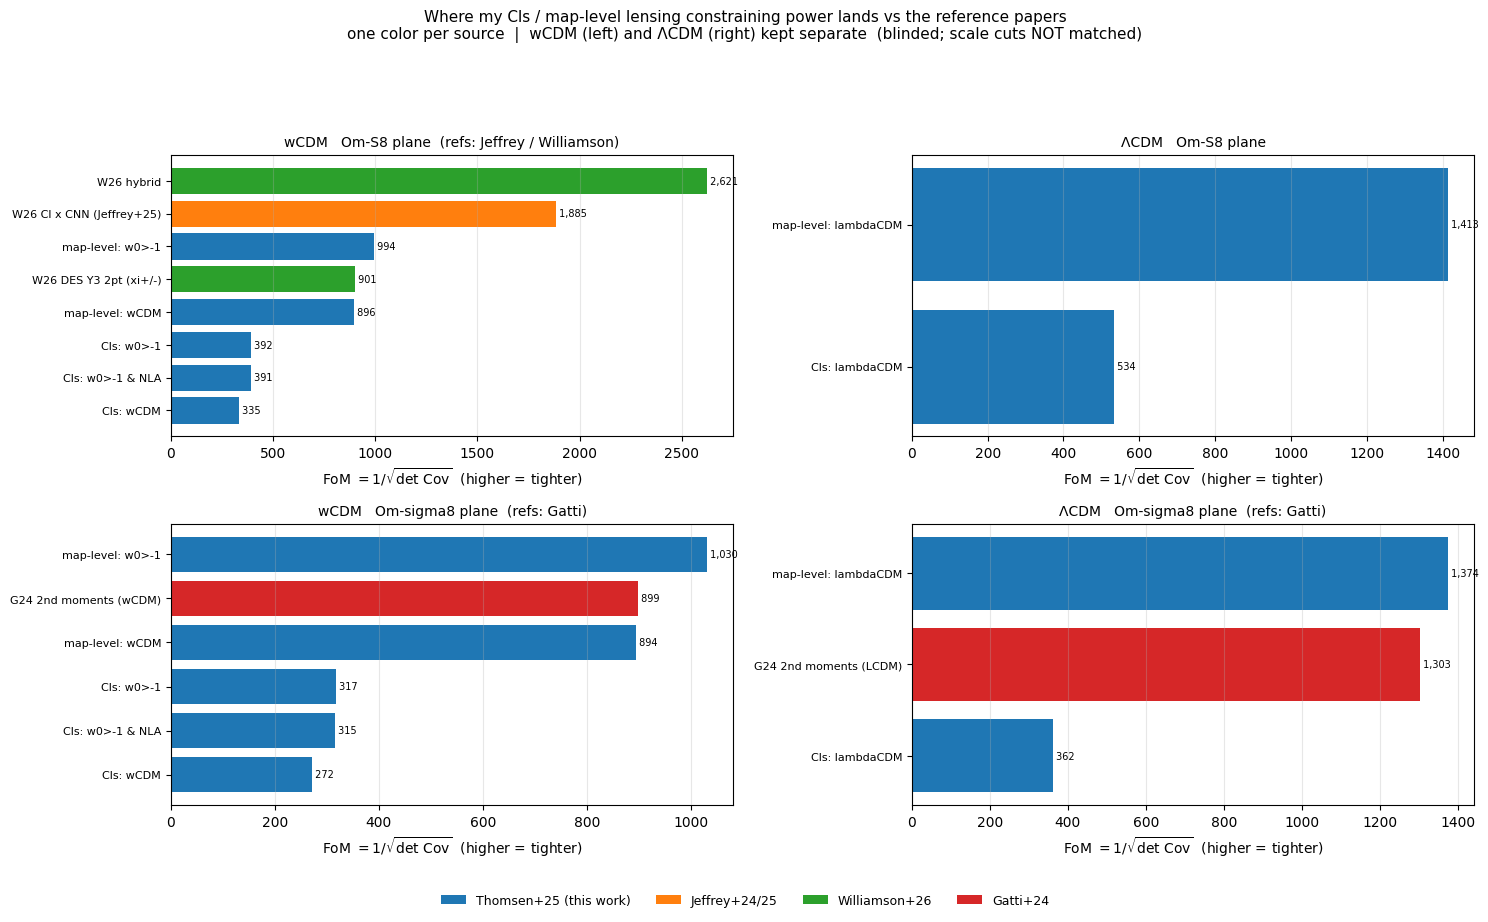

In [16]:
import pandas as pd
from matplotlib.patches import Patch

def overview_bar(ax, plane, model, title):
    """Sorted horizontal bars for ONE (plane, model), colored by source. wCDM and ΛCDM never share
    an axis -- comparing FoM across dark-energy models is not meaningful, so they get separate panels."""
    fk = ",".join(plane)
    entries = []  # (label, value, paper)
    for k, (ch, lp, cp) in CHAINS.items():
        if VAR_MODEL[k] == model and can_fom(cp, plane):
            entries.append((k, int(round(fom(ch, cp, plane))), "Thomsen"))
    for k, r in REF_CHAINS.items():
        if ref_model(r) == model and can_fom(r["params"], plane):
            entries.append((k, int(round(fom(r["chain"], r["params"], plane))), r["paper"]))
    for k, d in LIT.items():
        if lit_model(d) == model and fk in d.get("FoM", {}):
            entries.append((k, d["FoM"][fk], d["paper"]))
    if not entries:
        ax.set_title(title + "\n(no data)", fontsize=9); ax.axis("off"); return
    entries.sort(key=lambda e: e[1])
    vals = [e[1] for e in entries]
    ax.barh(range(len(entries)), vals, color=[color_of(e[2]) for e in entries])
    ax.set_yticks(range(len(entries)))
    ax.set_yticklabels([e[0] for e in entries], fontsize=8)
    for i, v in enumerate(vals):
        ax.text(v, i, f" {v:,}", va="center", fontsize=7)
    ax.set_xlabel(r"FoM $=1/\sqrt{\det\,\mathrm{Cov}}$  (higher = tighter)")
    ax.set_title(title, fontsize=10); ax.grid(axis="x", alpha=0.3)

PLANES = [(["Om", "S8"], "Om-S8"), (["Om", "s8"], "Om-sigma8")]  # rows
MODELS = ["wCDM", "ΛCDM"]                                        # columns
REFS_BY = {("Om-S8", "wCDM"): "  (refs: Jeffrey / Williamson)",
           ("Om-sigma8", "wCDM"): "  (refs: Gatti)", ("Om-sigma8", "ΛCDM"): "  (refs: Gatti)"}

fig, axes = plt.subplots(len(PLANES), len(MODELS), figsize=(15, 9))
for i, (plane, plabel) in enumerate(PLANES):
    for j, model in enumerate(MODELS):
        overview_bar(axes[i, j], plane, model,
                     f"{model}   {plabel} plane" + REFS_BY.get((plabel, model), ""))

handles = [Patch(facecolor=color_of(p), label=PAPER_LABEL[p]) for p in ["Thomsen", "Jeffrey", "Williamson", "Gatti"]]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9, frameon=False, bbox_to_anchor=(0.5, -0.01))
fig.suptitle("Where my Cls / map-level lensing constraining power lands vs the reference papers\n"
             "one color per source  |  wCDM (left) and ΛCDM (right) kept separate  (blinded; scale cuts NOT matched)",
             y=1.0, fontsize=11)
plt.tight_layout(rect=[0, 0.04, 1, 0.93]); plt.show()

In [17]:
# Same information as a table, grouped by model. Blanks = plane a source does not report.
FOM_COMPARE_KEYS = ["Om,s8", "Om,S8", "Om,S8,w0"]

rows = []
for k, (ch, lp, cp) in CHAINS.items():
    run, variant = k.split(": ", 1)
    r = {"label": k, "paper": "Thomsen", "model": VAR_MODEL[k],
         "stat": "map-level (NN)" if run == MAP_RUN["label"] else "lensing Cl (2pt)"}
    for fk in FOM_COMPARE_KEYS:
        if can_fom(cp, fk.split(",")):
            r[f"FoM({fk})"] = int(round(fom(ch, cp, fk.split(","))))
    rows.append(r)
for k, rc in REF_CHAINS.items():
    r = {"label": k, "paper": rc["paper"], "model": ref_model(rc), "stat": rc["stat"]}
    for fk in FOM_COMPARE_KEYS:
        if can_fom(rc["params"], fk.split(",")):
            r[f"FoM({fk})"] = int(round(fom(rc["chain"], rc["params"], fk.split(","))))
    rows.append(r)
for k, d in LIT.items():
    r = {"label": k, "paper": d["paper"], "model": lit_model(d), "stat": d["stat"]}
    for fk, val in d.get("FoM", {}).items():
        if fk in FOM_COMPARE_KEYS:
            r[f"FoM({fk})"] = val
    rows.append(r)

fom_overview = pd.DataFrame(rows).set_index("label")
fom_overview = fom_overview[["paper", "model", "stat"] + [f"FoM({k})" for k in FOM_COMPARE_KEYS if f"FoM({k})" in fom_overview]]
fom_overview.sort_values(["model", "stat"])

,paper,model,stat,"FoM(Om,s8)","FoM(Om,S8)","FoM(Om,S8,w0)"
label,,,,,,
G24 2nd moments (wCDM),Gatti,wCDM,2nd moments,899.0,NaN,NaN
W26 DES Y3 2pt (xi+/-),Williamson,wCDM,2pt xi+/-,NaN,901.0,10344.0
J24 map-level Cl x CNN,Jeffrey,wCDM,Cl x CNN (map),NaN,NaN,NaN
W26 Cl x CNN (Jeffrey+25),Jeffrey,wCDM,Cl x CNN (map),NaN,1885.0,18430.0
W26 hybrid,Williamson,wCDM,hybrid map stats,NaN,2621.0,29422.0
Cls: wCDM,Thomsen,wCDM,lensing Cl (2pt),272.0,335.0,1914.0
Cls: w0>-1,Thomsen,wCDM,lensing Cl (2pt),317.0,392.0,2855.0
Cls: w0>-1 & NLA,Thomsen,wCDM,lensing Cl (2pt),315.0,391.0,2687.0
J24 power spectrum (Cl),Jeffrey,wCDM,lensing Cl (2pt),NaN,NaN,NaN


## Detail: FoM table (run × variant)

Every loaded run/variant, all FoM planes (the `...,w0` columns are blank for `lambdaCDM`). Higher =
tighter; blinding-safe.

In [18]:
FOM_SETS = [["Om", "s8"], ["Om", "S8"], ["Om", "s8", "w0"], ["Om", "S8", "w0"]]

rows = []
for key, (chain, lp, cp) in CHAINS.items():
    run, variant = key.split(": ", 1)
    row = {"run": run, "variant": variant, "model": VAR_MODEL[key]}
    for s in FOM_SETS:
        if can_fom(cp, s):
            row["FoM(" + ",".join(s) + ")"] = int(round(fom(chain, cp, s)))
    rows.append(row)
fom_table = pd.DataFrame(rows).set_index(["run", "variant"])
fom_table

model  FoM(Om,s8)  FoM(Om,S8)  FoM(Om,s8,w0)  \
run       variant                                                    
Cls       wCDM         wCDM         272         335         1330.0   
          w0>-1        wCDM         317         392         2104.0   
          w0>-1 & NLA  wCDM         315         391         2037.0   
          lambdaCDM    ΛCDM         362         534            NaN   
map-level wCDM         wCDM         894         896         5099.0   
          w0>-1        wCDM        1030         994         7642.0   
          lambdaCDM    ΛCDM        1374        1413            NaN   

                       FoM(Om,S8,w0)  
run       variant                     
Cls       wCDM                1914.0  
          w0>-1               2855.0  
          w0>-1 & NLA         2687.0  
          lambdaCDM              NaN  
map-level wCDM                5093.0  
          w0>-1               7352.0  
          lambdaCDM              NaN

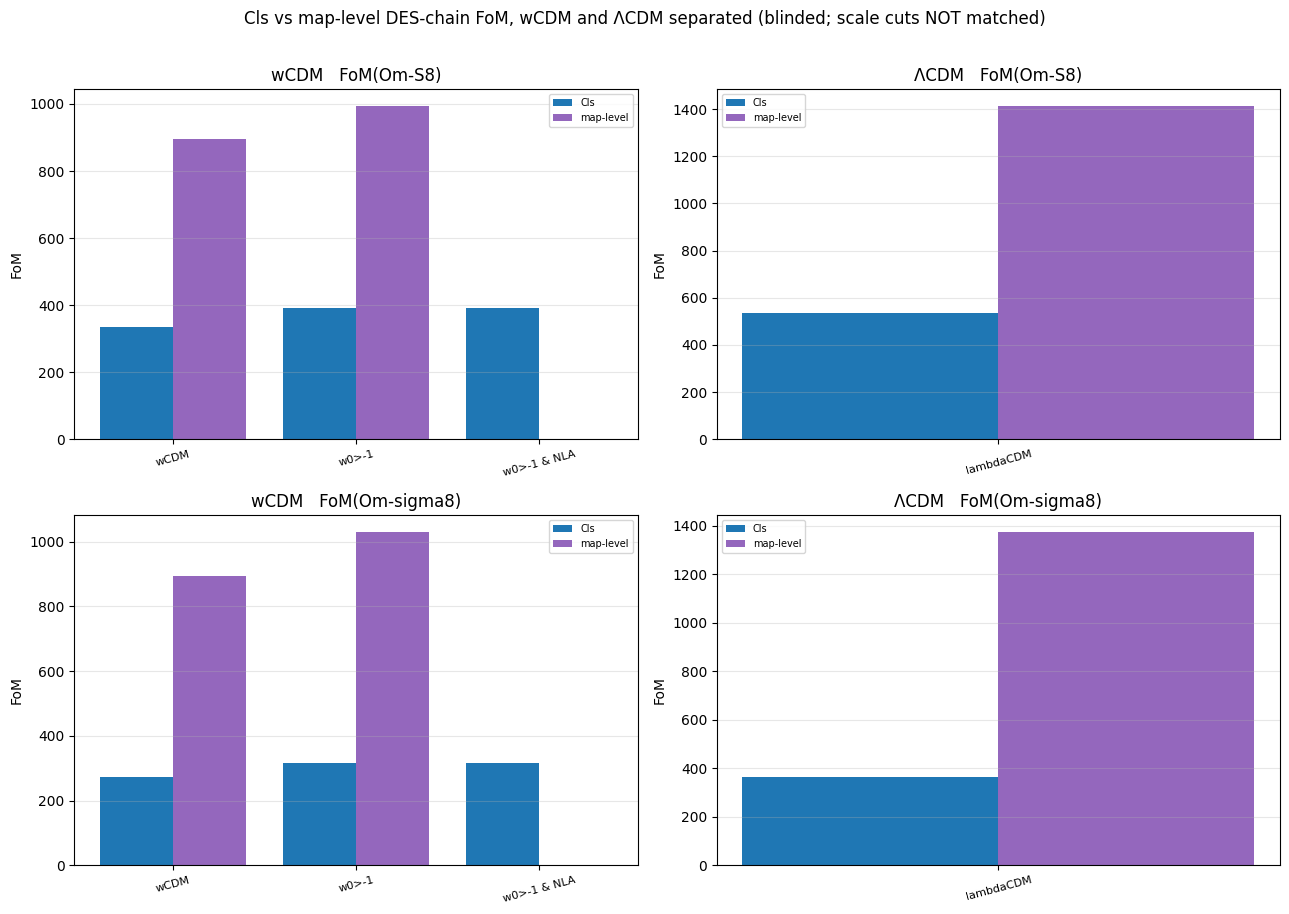

In [19]:
# Cls vs map-level, grouped by variant, in both planes -- wCDM and ΛCDM kept in separate columns.
variants_by_model = {}
for k in CHAINS:
    variant = k.split(": ", 1)[1]
    variants_by_model.setdefault(VAR_MODEL[k], [])
    if variant not in variants_by_model[VAR_MODEL[k]]:
        variants_by_model[VAR_MODEL[k]].append(variant)
run_labels = [r["label"] for r in RUNS]
PLANES = [(["Om", "S8"], "Om-S8"), (["Om", "s8"], "Om-sigma8")]  # rows
MODELS = ["wCDM", "ΛCDM"]                                        # columns

fig, axes = plt.subplots(len(PLANES), len(MODELS), figsize=(13, 9))
for i, (plane, plabel) in enumerate(PLANES):
    for j, model in enumerate(MODELS):
        ax = axes[i, j]
        vs = variants_by_model.get(model, [])
        x = np.arange(len(vs)); w = 0.8 / max(1, len(run_labels))
        for jj, rl in enumerate(run_labels):
            vals = [int(round(fom(CHAINS[f"{rl}: {v}"][0], CHAINS[f"{rl}: {v}"][2], plane)))
                    if f"{rl}: {v}" in CHAINS else 0 for v in vs]
            ax.bar(x + jj * w, vals, w, label=rl, color=MINE_COLORS[jj % len(MINE_COLORS)])
        ax.set_xticks(x + w * (len(run_labels) - 1) / 2)
        ax.set_xticklabels(vs, fontsize=8, rotation=15)
        ax.set_title(f"{model}   FoM({plabel})"); ax.set_ylabel("FoM")
        ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=7)
fig.suptitle("Cls vs map-level DES-chain FoM, wCDM and ΛCDM separated (blinded; scale cuts NOT matched)", y=1.01)
plt.tight_layout(); plt.show()

## Detail: blinded contour overlay (Cls vs map-level)

For each shared variant, overlay the two runs (shifted to fiducial), in `sigma8` and `S8`. Compare
**sizes** only. `w0>-1` / `lambdaCDM` are the cleanest cross-run comparisons; `w0>-1 & NLA` is Cls-only.

My two runs use two shades of the "this work" palette (blue = Cls, purple = map-level) so they stay
distinguishable within a panel; the **Williamson+26 hybrid** chain is overlaid in green on the `w0>-1`
panels (matched w0 prior) as an actual published contour to compare against.

26-07-10 14:34:47     prior.py INF   Assessing prior boundaries in ['Om', 'S8'] for chain in ['Om', 'S8'] 
26-07-10 14:34:47     prior.py INF   Prior boundary assessment (blinded)  any_pressing=False 
26-07-10 14:34:47     prior.py INF   Assessing prior boundaries in ['Om', 'S8'] for chain in ['Om', 'S8'] 
26-07-10 14:34:47     prior.py INF   Prior boundary assessment (blinded)  any_pressing=False 
26-07-10 14:34:48     prior.py INF   Assessing prior boundaries in ['Om', 'S8'] for chain in ['Om', 'S8'] 
26-07-10 14:34:48     prior.py INF   Prior boundary assessment (blinded)  any_pressing=False 
26-07-10 14:34:49     prior.py INF   Assessing prior boundaries in ['Om', 'S8', 'w0'] for chain in ['Om', 'S8', 'w0'] 
26-07-10 14:34:49     prior.py INF   Prior boundary assessment (blinded)  any_pressing=False 
26-07-10 14:34:50     prior.py INF   Assessing prior boundaries in ['Om', 'S8', 'w0'] for chain in ['Om', 'S8', 'w0'] 
26-07-10 14:34:50     prior.py INF   Prior boundary assessment (b

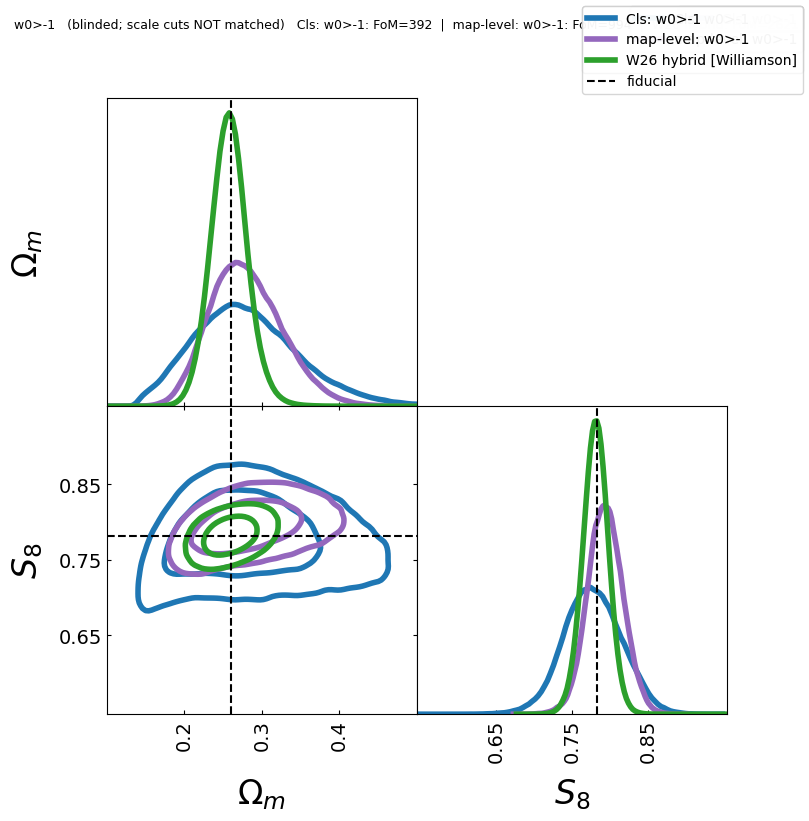

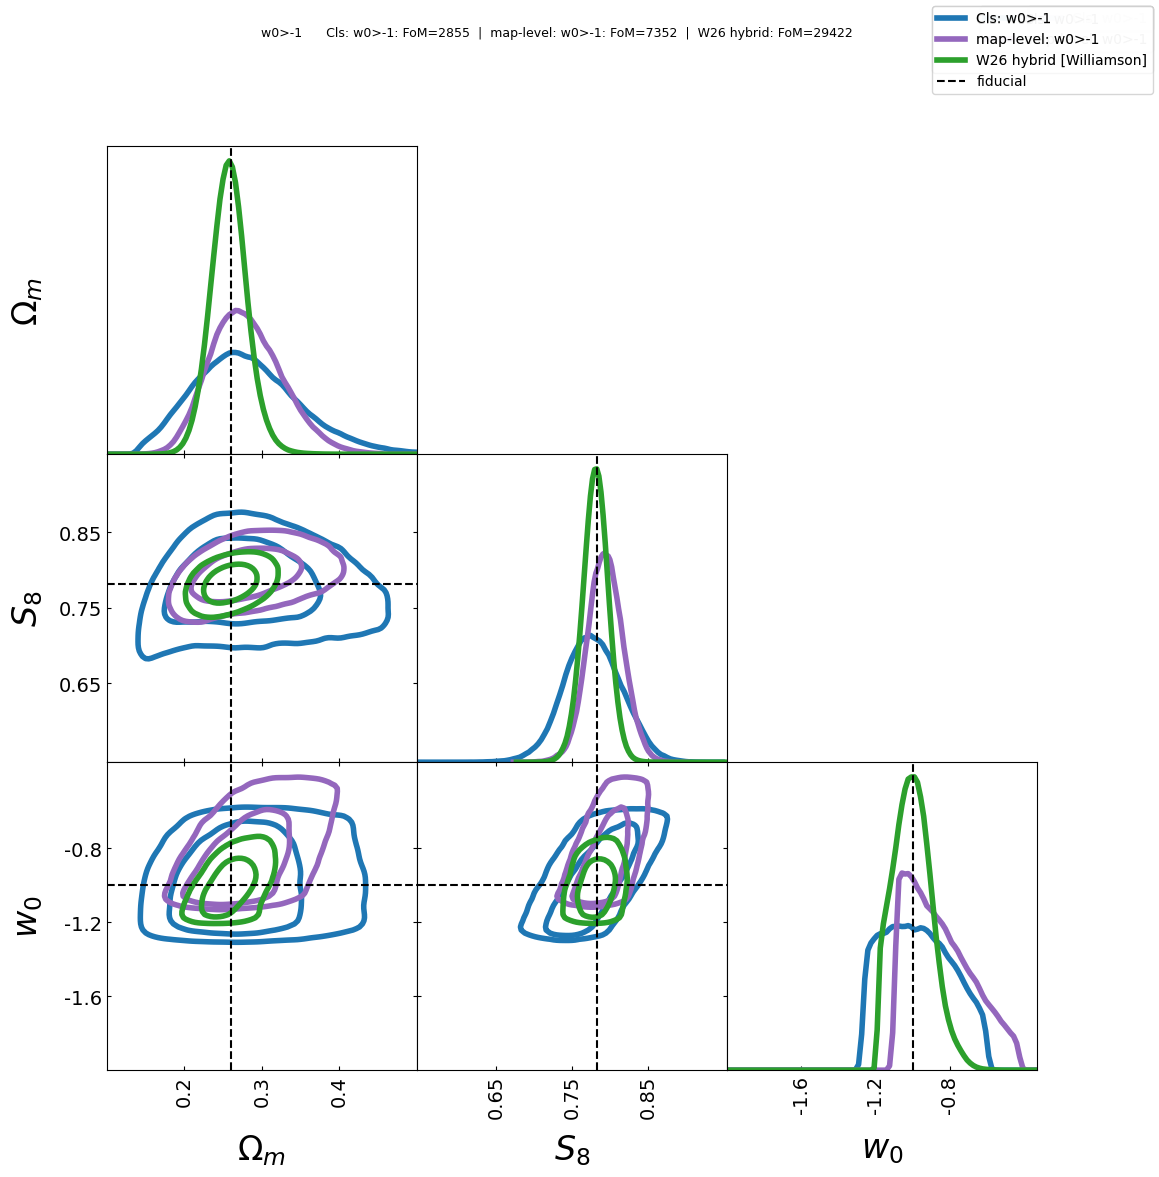

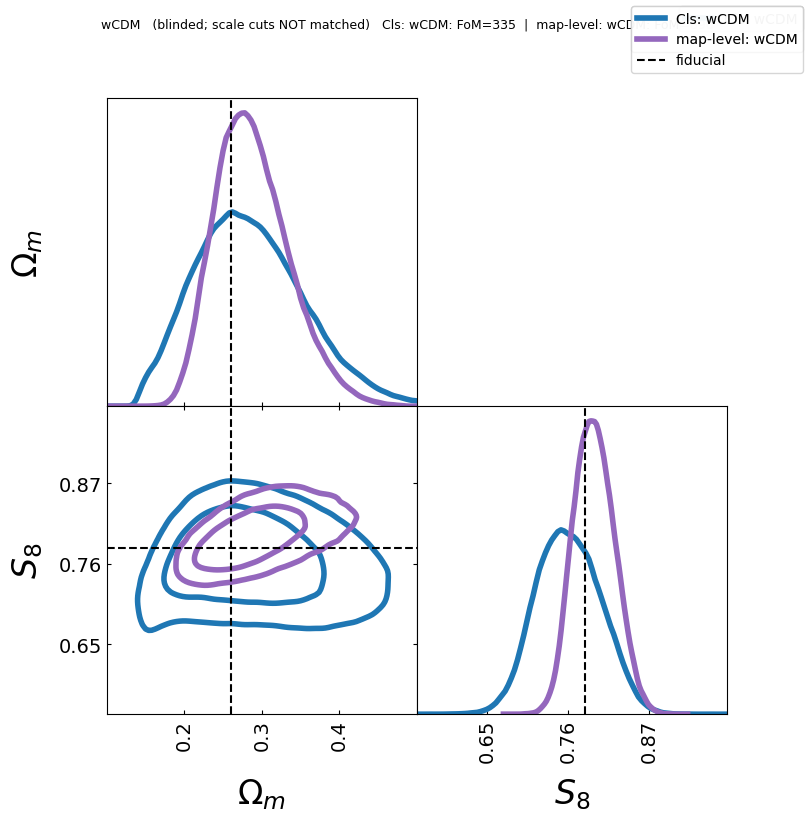

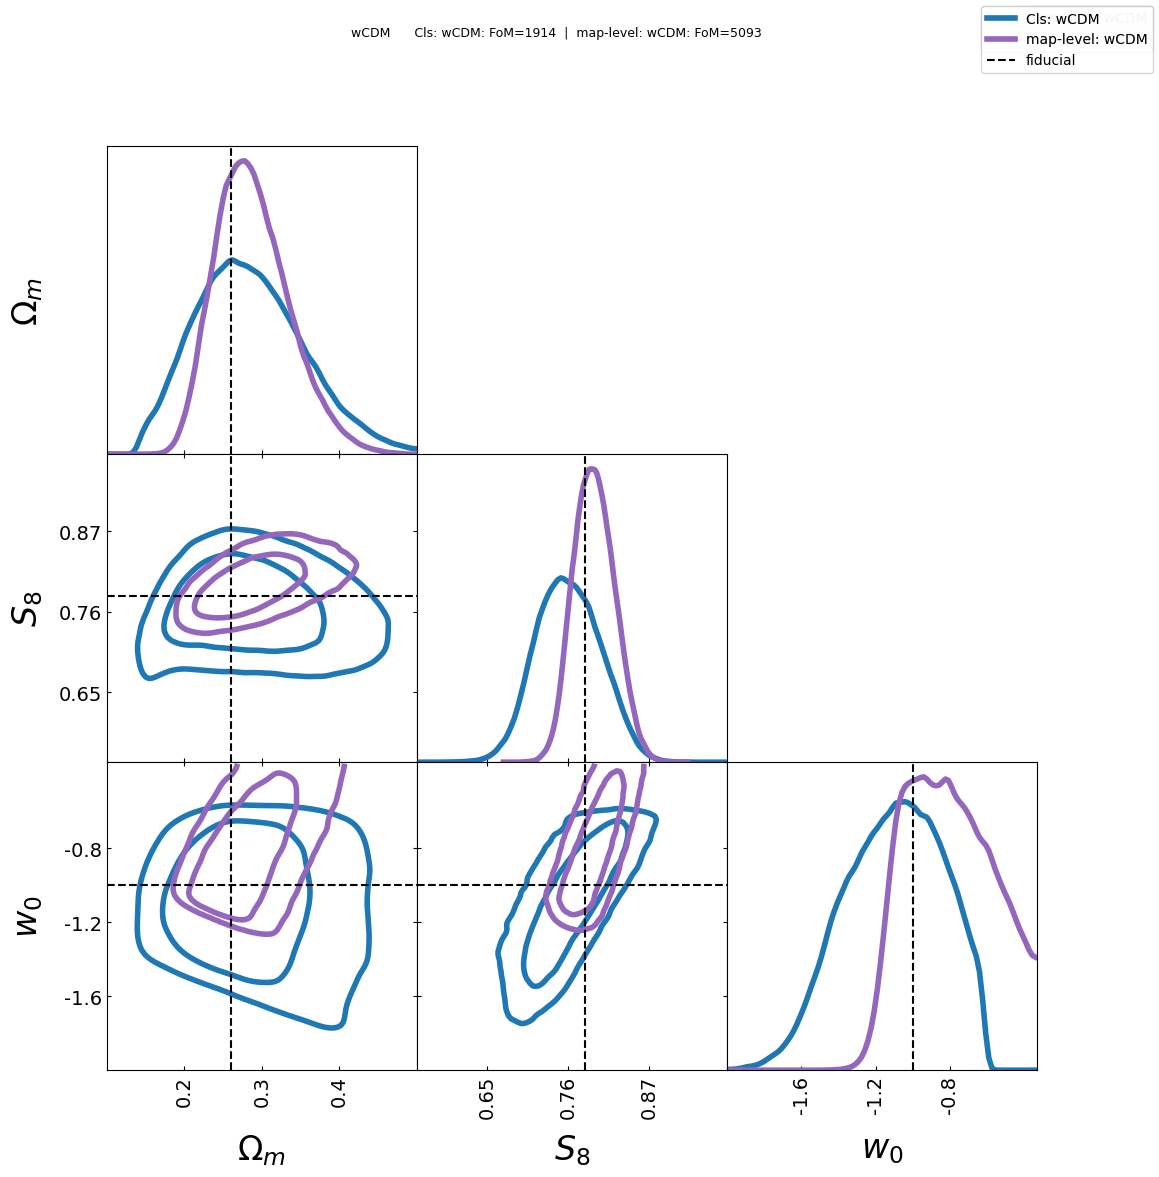

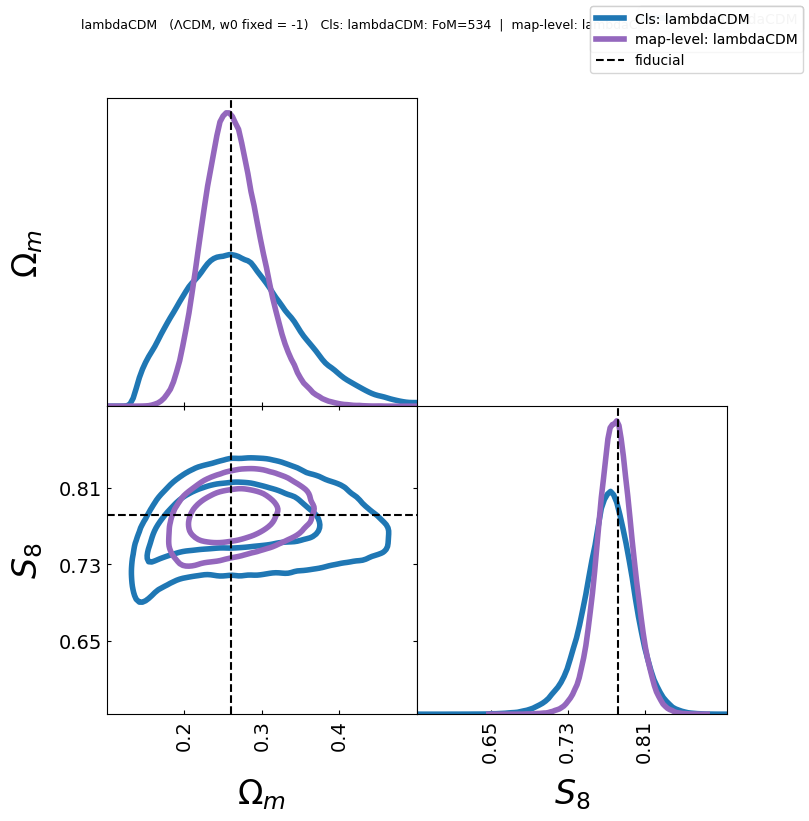

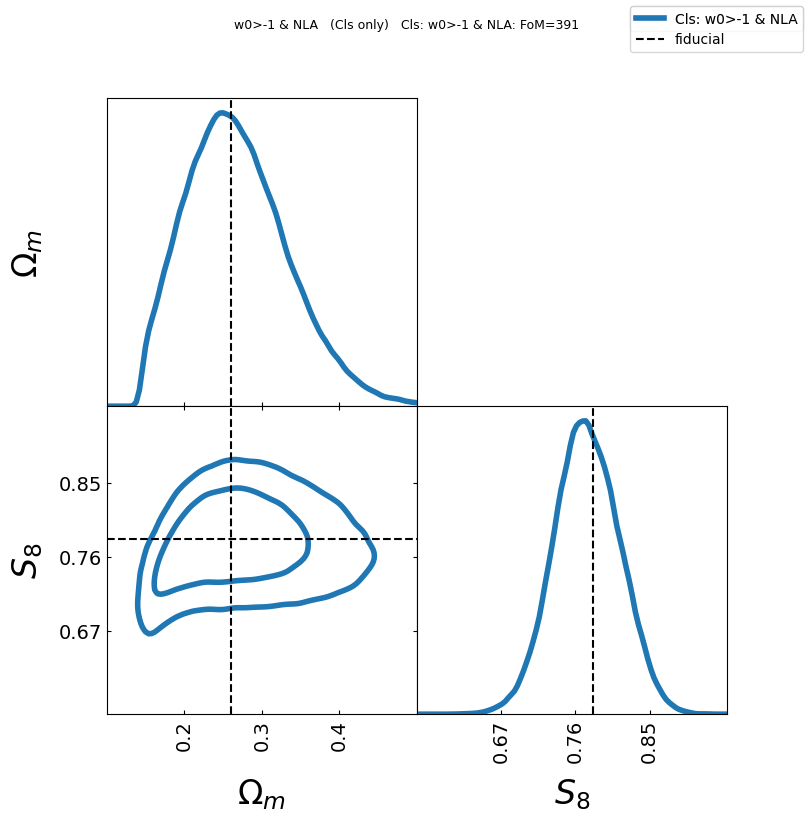

In [20]:
from trianglechain import TriangleChain

# My two runs get two shades of the "this work" palette (MINE_COLORS, defined in the config cell) so
# they stay distinguishable within a panel; reference chains use their per-paper color.
def compare_runs(variant, test_params, title=""):
    keys = [k for k in CHAINS if k.endswith(f": {variant}")]
    refs = [(rk, r) for rk, r in REF_CHAINS.items()
            if variant in r.get("variants", []) and can_fom(r["params"], test_params)]
    if not keys and not refs:
        print(f"no chains for variant {variant!r}"); return None
    ref = parameters.get_fiducials(test_params, msfm_conf)
    ranges = {p: parameters.get_prior_intervals([p], msfm_conf)[0] for p in test_params if p != "S8"}
    tri = TriangleChain(names=test_params, labels=[plotting.param_label_dict[p] for p in test_params],
                        ranges=ranges, fill=False, show_legend=True,
                        axlines_kwargs={"linestyle": "--"}, progress_bar=False)
    parts = []
    for i, k in enumerate(keys):
        chain, lp, cp = CHAINS[k]
        tri.contour_cl(shifted(chain, lp, cp, test_params), names=test_params, label=k,
                       color=MINE_COLORS[i % len(MINE_COLORS)])
        if len(test_params) >= 2:
            parts.append(f"{k}: FoM={int(round(fom(chain, cp, test_params)))}")
    for rk, r in refs:
        tri.contour_cl(shifted(r["chain"], None, r["params"], test_params), names=test_params,
                       label=f"{rk} [{r['paper']}]", color=color_of(r["paper"]))
        if len(test_params) >= 2:
            parts.append(f"{rk}: FoM={int(round(fom(r['chain'], r['params'], test_params)))}")
    tri.axlines(ref[np.newaxis], names=test_params, color="k", label="fiducial")
    tri.fig.suptitle((f"{variant}   " + title + "   " + "  |  ".join(parts)).strip(), fontsize=9)
    return tri

# Each variant is its own figure, so wCDM and ΛCDM are already never mixed in one panel.
# w0>-1 also overlays the Williamson+26 hybrid chain (matched w0 prior).
for variant in ["w0>-1", "wCDM"]:
    compare_runs(variant, ["Om", "S8"], title="(blinded; scale cuts NOT matched)")
    compare_runs(variant, ["Om", "S8", "w0"])
compare_runs("lambdaCDM", ["Om", "S8"], title="(ΛCDM, w0 fixed = -1)")
compare_runs("w0>-1 & NLA", ["Om", "S8"], title="(Cls only)")
plt.show()

## Detail: constraining power across parameter space (held-out mocks)

Per-observation Ωm–S8 FoM over each run's held-out mock grid (`mcmc_samples.h5`, wCDM posteriors, no
shift needed). Left/middle: each run's FoM vs true cosmology. Right: the map-level/Cls FoM **ratio** at
matched `real_idx` — where the map level helps most (again folding in the unmatched scale cut + steps).

Cls        n_obs=1000  median FoM(Om,S8)=544
map-level  n_obs=1000  median FoM(Om,S8)=1168


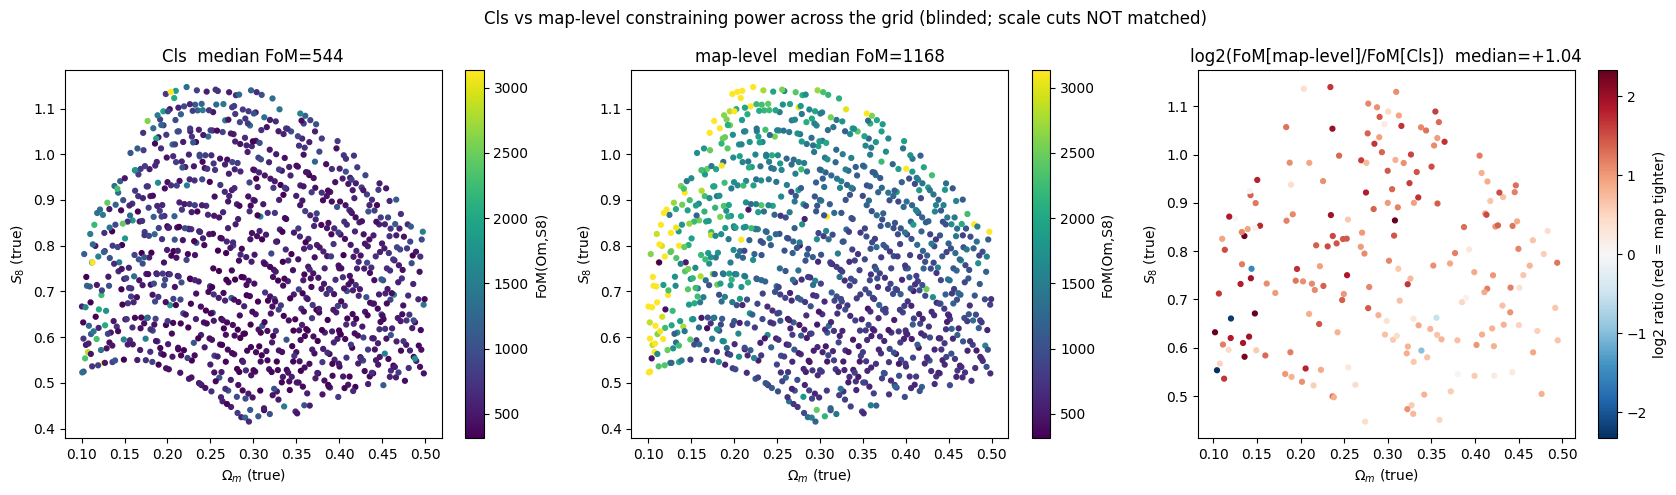

In [21]:
import h5py

def s8_of(sigma8, Om):
    return sigma8 * np.sqrt(Om / 0.3)

def per_obs_fom_2d(a, b):
    am = a - a.mean(0); bm = b - b.mean(0)
    caa = (am * am).mean(0); cbb = (bm * bm).mean(0); cab = (am * bm).mean(0)
    return 1.0 / np.sqrt(np.clip(caa * cbb - cab ** 2, 1e-30, None))

def load_grid(run):
    mf = os.path.join(run["fdir"], "mcmc_samples.h5")
    if not os.path.exists(mf):
        print(f"[missing] {run['label']}: no mcmc_samples.h5"); return None
    with h5py.File(mf, "r") as f:
        tt = f["theta_true"][:]; ts = f["theta_sample"][:]
        ridx = f["real_idx"][:] if "real_idx" in f else None
    i_om, i_s8 = PARAMS.index("Om"), PARAMS.index("s8")
    om_s = ts[:, :, i_om]; om_t = tt[:, i_om]
    return dict(fom=per_obs_fom_2d(om_s, s8_of(ts[:, :, i_s8], om_s)),
                om_true=om_t, s8_true=s8_of(tt[:, i_s8], om_t), real_idx=ridx)

grid = {r["label"]: load_grid(r) for r in RUNS}
grid = {k: v for k, v in grid.items() if v is not None}
for k, g in grid.items():
    print(f"{k:10s} n_obs={len(g['fom']):4d}  median FoM(Om,S8)={np.median(g['fom']):.0f}")

present = list(grid)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
if present:
    vmin, vmax = np.percentile(np.concatenate([grid[k]["fom"] for k in present]), [2, 98])
    for ax, k in zip(axes[:2], present):
        d = grid[k]
        sc = ax.scatter(d["om_true"], d["s8_true"], c=d["fom"], s=12, cmap="viridis", vmin=vmin, vmax=vmax)
        ax.set(xlabel=r"$\Omega_m$ (true)", ylabel=r"$S_8$ (true)",
               title=f"{k}  median FoM={np.median(d['fom']):.0f}")
        fig.colorbar(sc, ax=ax, label="FoM(Om,S8)")
    for ax in axes[len(present):2]:
        ax.axis("off")
    ax = axes[2]
    if len(present) == 2 and all(grid[k]["real_idx"] is not None for k in present):
        num, den = grid[MAP_RUN["label"]], grid[CLS_RUN["label"]]
        key = lambda ri: [tuple(int(v) for v in row) for row in ri]
        dmap = {t: i for i, t in enumerate(key(den["real_idx"]))}
        common = [(i, dmap[t]) for i, t in enumerate(key(num["real_idx"])) if t in dmap]
        if common:
            ii = np.array([a for a, _ in common]); jj = np.array([b for _, b in common])
            ratio = np.log2(num["fom"][ii] / den["fom"][jj])
            lim = np.percentile(np.abs(ratio), 98)
            sc = ax.scatter(num["om_true"][ii], num["s8_true"][ii], c=ratio, s=12,
                            cmap="RdBu_r", vmin=-lim, vmax=lim)
            ax.set(xlabel=r"$\Omega_m$ (true)", ylabel=r"$S_8$ (true)",
                   title=f"log2(FoM[{MAP_RUN['label']}]/FoM[{CLS_RUN['label']}])  median={np.median(ratio):+.2f}")
            fig.colorbar(sc, ax=ax, label="log2 ratio (red = map tighter)")
        else:
            ax.set_title("no matched observations"); ax.axis("off")
    else:
        ax.set_title("ratio needs both runs + real_idx"); ax.axis("off")
fig.suptitle("Cls vs map-level constraining power across the grid (blinded; scale cuts NOT matched)")
plt.tight_layout(); plt.show()

### Error-bar comparison (widths only; blinding-safe)

Marginal 1-sigma of each run/variant vs the literature half-widths `(+err -err)/2`. Compare the
**Cls** rows to J24 *power spectrum*, the **map-level** rows to the `Cl x CNN` entries; G24 for ΛCDM.

In [22]:
rows = []
for k in CHAINS:
    run = k.split(": ", 1)[0]
    rows.append({"label": k, "paper": "Thomsen", "model": VAR_MODEL[k],
                 "stat": "map-level (NN)" if run == MAP_RUN["label"] else "lensing Cl (2pt)",
                 "sig(Om)": marg_sig(k, "Om"), "sig(S8)": marg_sig(k, "S8"), "sig(s8)": marg_sig(k, "s8")})
for k, rc in REF_CHAINS.items():
    rows.append({"label": k, "paper": rc["paper"], "model": ref_model(rc), "stat": rc["stat"],
                 "sig(Om)": marg_sig_of(rc["chain"], rc["params"], "Om"),
                 "sig(S8)": marg_sig_of(rc["chain"], rc["params"], "S8"),
                 "sig(s8)": marg_sig_of(rc["chain"], rc["params"], "s8")})
for k, d in LIT.items():
    rows.append({"label": k, "paper": d["paper"], "model": lit_model(d), "stat": d["stat"],
                 "sig(Om)": _half(d.get("Om")), "sig(S8)": _half(d.get("S8")), "sig(s8)": _half(d.get("s8"))})
err_table = pd.DataFrame(rows).set_index("label")[["paper", "model", "stat", "sig(Om)", "sig(S8)", "sig(s8)"]]
err_table.round(4)

,paper,model,stat,sig(Om),sig(S8),sig(s8)
label,,,,,,
Cls: wCDM,Thomsen,wCDM,lensing Cl (2pt),0.0699,0.0429,0.1449
Cls: w0>-1,Thomsen,wCDM,lensing Cl (2pt),0.0671,0.0380,0.1370
Cls: w0>-1 & NLA,Thomsen,wCDM,lensing Cl (2pt),0.0653,0.0395,0.1423
Cls: lambdaCDM,Thomsen,ΛCDM,lensing Cl (2pt),0.0706,0.0267,0.1382
map-level: wCDM,Thomsen,wCDM,map-level (NN),0.0475,0.0275,0.0520
map-level: w0>-1,Thomsen,wCDM,map-level (NN),0.0461,0.0235,0.0512
map-level: lambdaCDM,Thomsen,ΛCDM,map-level (NN),0.0382,0.0193,0.0496
W26 hybrid,Williamson,wCDM,hybrid map stats,0.0239,0.0171,NaN
J24 power spectrum (Cl),Jeffrey,wCDM,lensing Cl (2pt),0.0440,0.0260,NaN


### Caveats (read before interpreting)

- **Scale cuts are NOT matched** and **training steps differ** (Cls 1M vs map-level 150k). A
  Cls-vs-map difference mixes statistic + scale cut + training budget — *indicative only*. For a clean
  statement, rerun the map-level model at the matched `lmax_1024` cut and a comparable step.
- **Blinding:** only sizes / error bars / FoM are meaningful; central values are shifted to fiducial.
- **wCDM vs ΛCDM:** never compared directly — the overview and grouped-bar figures keep them in
  separate columns on independent scales. FoM only means the same thing within one dark-energy model.
- **Plane matters:** `FoM(Om,S8) != FoM(Om,sigma8)`. Overview top row (`Om-S8`) → Jeffrey / Williamson;
  bottom row (`Om-sigma8`) → Gatti.
- **w0 prior matters:** the `...,w0` FoM only compares within a matched w0 range → use `w0>-1`
  (w0 in (-1,-1/3)), not `wCDM` (w0 in (-2,-1/3)). ΛCDM fixes w0=-1, so it has no w0 FoM.
- **Cls-only vs map-level:** J24 power spectrum is the Cls analogue; map-level `Cl x CNN` and moments
  are more informative, so expect your Cls FoM **below** them and the map-level run **closer**.
- **Calibration != constraining power:** a higher FoM is only real if calibrated — check SBC/TARP/HPD
  in each run's `unblinding_plots/` first.